In [2]:
import pandas as pd
import numpy as np
import ast

def load_ecotox_data(
    adore_path,
    chemicals_path,
    # -- Optional concentration choice --
    use_molar=True,
    mol_col="result_conc1_mean_mol_log",
    mg_col="result_conc1_mean_log",
    # -- Selfies options --
    use_selfies=False,
    selfies_path=None,
    selfies_col="selfies_embed",
    # -- Mol2Vec options --
    use_mol2vec=False,
    mol2vec_path=None,
    mol2vec_cols=None,
    # -- Fingerprint options --
    use_fingerprint=False,
    fingerprint_path=None,
    fp_col="morgan_fp",
    # -- Misc --
    shuffle=True,
    random_state=42
):
    adore = pd.read_csv(adore_path, low_memory=False)
    chemicals = pd.read_csv(chemicals_path, low_memory=False)

    df = adore.merge(chemicals, on='test_cas', how='left')
    df.rename(columns={
        'tax_gs': 'species',
        'test_cas': 'CAS',
        'result_obs_duration_mean': 'duration'
    }, inplace=True)

    target_col = mol_col if use_molar else mg_col
    if target_col not in df.columns:
        raise ValueError(
            f"Chosen target_col='{target_col}' not found in the merged DataFrame. "
            "Check your ADORE/chemicals CSV for the correct column name."
        )
    df.rename(columns={target_col: 'conc'}, inplace=True)

    df['species'] = pd.Categorical(df['species'])
    df['CAS'] = pd.Categorical(df['CAS'])
    df['duration'] = df['duration'].astype(float)

    if shuffle:
        df = df.sample(frac=1, random_state=random_state).reset_index(drop=True)

    y_mean = df['conc'].mean()
    df['conc_centered'] = df['conc'] - y_mean

    return df, df['conc_centered'].values




In [3]:
adore_path = '../data_files/ecotox_mortality_processed.csv'
chemicals_path = '../data_files/ecotox_properties_with-oecd-function.csv'

full_data, y_centered = load_ecotox_data(
    adore_path=adore_path,
    chemicals_path = chemicals_path,
    use_selfies=False,
    use_mol2vec=False,
    use_fingerprint=False,
    shuffle=True,
    random_state=42,
)

In [4]:
num_unique_obs = full_data.drop_duplicates(subset=['CAS', 'species', 'duration']).shape[0]
num_unique_obs


31319

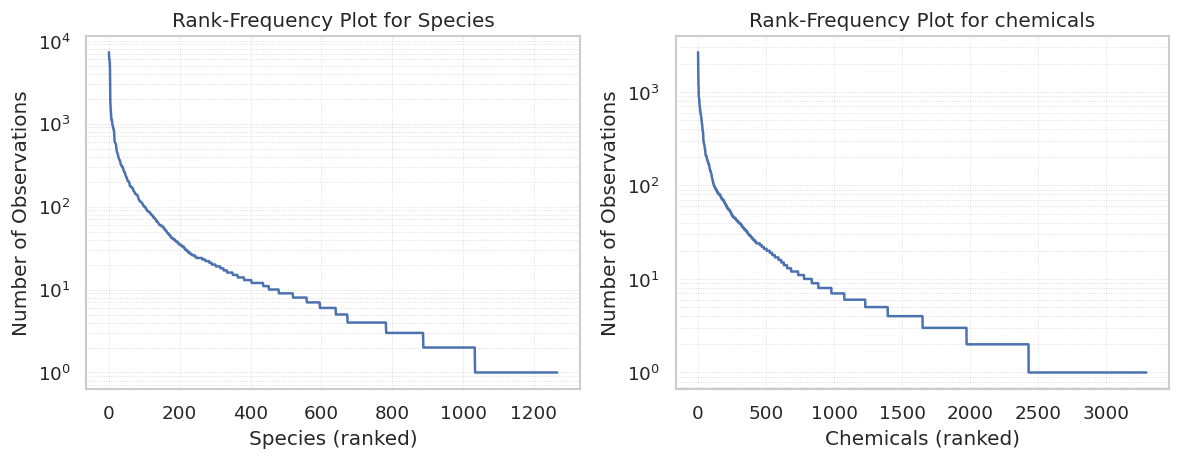

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt


species_counts   = full_data['species'].value_counts()
chemical_counts  = full_data['CAS'].value_counts()

species_sorted   = species_counts.sort_values(ascending=False).reset_index(drop=True)
chemical_sorted  = chemical_counts.sort_values(ascending=False).reset_index(drop=True)

sns.set_theme(style="whitegrid")        # gives the dotted grid you had

fig, axes = plt.subplots(1, 2, figsize=(10, 4), dpi=120)

sns.lineplot(
    ax   = axes[0],
    x    = species_sorted.index,        # rank 0, 1, 2, …
    y    = species_sorted.values,
    errorbar=None                       # silence seaborn-v0.13 warning
)
axes[0].set_yscale('log')
axes[0].set_xlabel('Species (ranked)')
axes[0].set_ylabel('Number of Observations')
axes[0].set_title('Rank-Frequency Plot for Species')
axes[0].grid(which='both', linestyle=':', linewidth=0.4)

sns.lineplot(
    ax   = axes[1],
    x    = chemical_sorted.index,
    y    = chemical_sorted.values,
    errorbar=None
)
axes[1].set_yscale('log')
axes[1].set_xlabel('Chemicals (ranked)')
axes[1].set_ylabel('Number of Observations')
axes[1].set_title('Rank-Frequency Plot for chemicals')
axes[1].grid(which='both', linestyle=':', linewidth=0.4)

plt.tight_layout()
plt.show()


/tmp/ipykernel_271867/4036527038.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(['species', 'CAS', 'duration'])['result_conc1_mean']     # group by pair


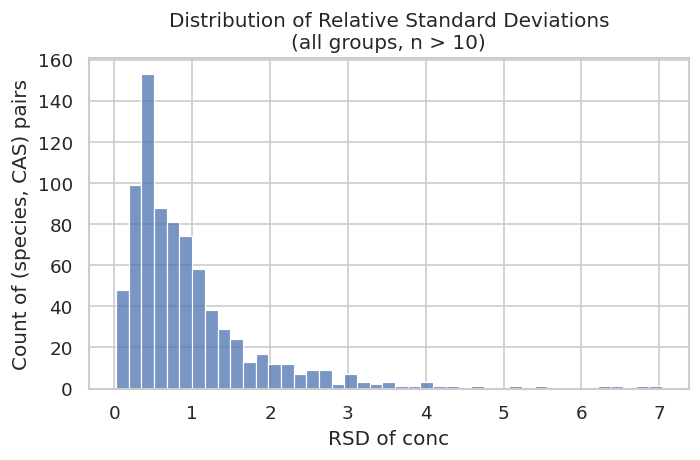

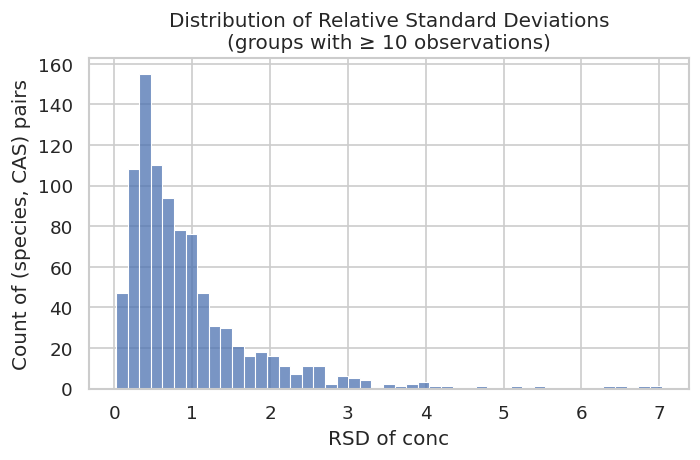

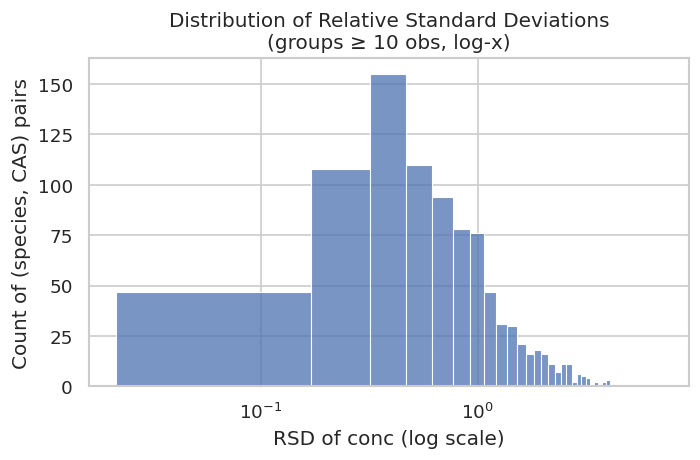

In [19]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

grouped_stats = (
    full_data # [full_data['duration'] == 48.0]              # keep 96-h tests
    .groupby(['species', 'CAS', 'duration'])['result_conc1_mean']     # group by pair
    .agg(['count', 'mean', 'std'])                        # n, μ, σ
    .reset_index()
)
grouped_stats_multiple = grouped_stats[grouped_stats['count'] > 10].copy()
grouped_stats_multiple['rsd'] = (
    grouped_stats_multiple['std'] / grouped_stats_multiple['mean']
)

grouped_stats_10 = grouped_stats[grouped_stats['count'] >= 10].copy()
grouped_stats_10['rsd'] = grouped_stats_10['std'] / grouped_stats_10['mean']

sns.set_theme(style="whitegrid")

plt.figure(figsize=(6, 4), dpi=120)
sns.histplot(grouped_stats_multiple['rsd'], kde=False)
plt.xlabel('RSD of conc')
plt.ylabel('Count of (species, CAS) pairs')
plt.title('Distribution of Relative Standard Deviations\n(all groups, n > 10)')
plt.tight_layout()
plt.show()

# --- (b) Pairs with ≥10 measurements ------------------------------------
plt.figure(figsize=(6, 4), dpi=120)
sns.histplot(grouped_stats_10['rsd'], kde=False)
plt.xlabel('RSD of conc')
plt.ylabel('Count of (species, CAS) pairs')
plt.title('Distribution of Relative Standard Deviations\n(groups with ≥ 10 observations)')
plt.tight_layout()
plt.show()

# --- (c) Same as (b) but log-x scale ------------------------------------
plt.figure(figsize=(6, 4), dpi=120)
sns.histplot(grouped_stats_10['rsd'], kde=False)
plt.xscale('log')
plt.xlabel('RSD of conc (log scale)')
plt.ylabel('Count of (species, CAS) pairs')
plt.title('Distribution of Relative Standard Deviations\n(groups ≥ 10 obs, log-x)')
plt.tight_layout()
plt.show()
